# Paper III: SMBH binaries with PLATO

TODO: write git version of last functional run!

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# PlatoSim libraries
import platosim.utilities as ut
from platosim.hpc          import HPC 
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Paths to where data is stored
path  = '/lhome/nicholas/software/workdir/cs-smbhb'
path0 = f'{path}/sim0_signal'
path1 = f'{path}/sim0_noise'
path2 = f'{path}/sim1_signal'
path3 = f'{path}/sim1_noise'

---
## Variable sources
---

### Generate files

In [4]:
hpc = HPC(cpus=6)
paramFile = f'{path}/data_varsource.txt'
# hpc.run(script='varsim', project='smbhb', paramFile=paramFile)

### Preview files

In [4]:
starID = f'{1}'.zfill(9)
df = pd.read_csv(f'{path}/varsource/varsource_{starID}.txt', sep=' ', names=['time', 'mag']) 

<IPython.core.display.Javascript object>


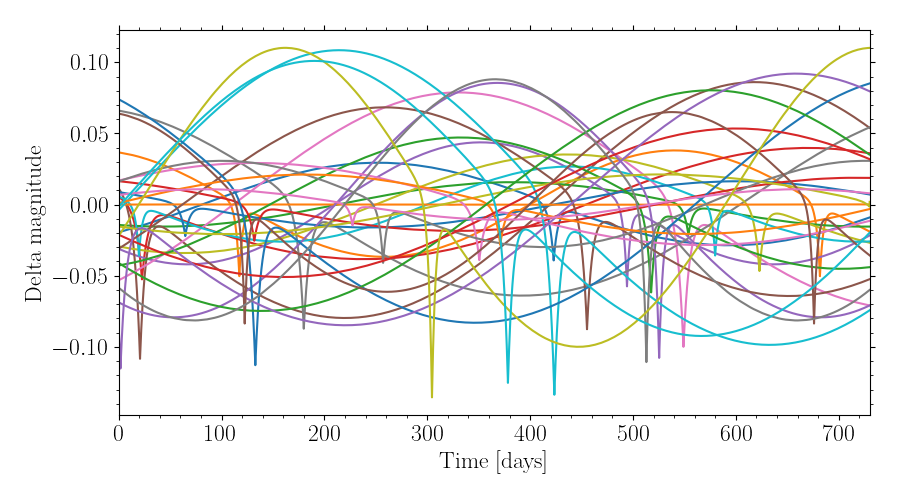

In [5]:
plt.figure(figsize=(9,5))
for i in range(30):
    starID = f'{i+1}'.zfill(9)
    df = pd.read_csv(f'{path}/varsource/varsource_{starID}.txt', sep=' ', names=['time', 'mag'])    
    plt.plot(df.time/86400, df.mag)
plt.xlabel('Time [days]')
plt.ylabel('Delta magnitude')
plt.xlim(0, df.time.max()/86400)
plt.tight_layout()

### Add magnitude column parameterisation file

In [137]:
starcat = f'{path}/input/starcat_P5_SPF_Ncam24_targets.ftr'
df = pd.read_feather(starcat)

In [16]:
# Generate 1000 random magnitudes reproducable using the seed=1000
rng = np.random.default_rng(seed=1000)
mag = rng.uniform(16, 19, 1000)

# Replace magnitude column in target catalogue
df.mag = mag
df = df.astype({'mag':np.float32})
df.head()

,index,ID,PIC,ra,dec,mag,sample,Teff,R,M,ncams,field,ncon
0,0,000000001,11571238,95.125555,-47.494494,17.564157,8,6322.698412,1.353938,1.240897,24,S,3
1,1,000000002,10612872,88.125215,-49.637731,17.811525,8,5133.584125,4.040686,1.500600,24,S,0
2,2,000000003,16373342,81.625712,-36.698203,17.412825,8,5864.912195,1.276711,1.123527,24,S,1
3,3,000000004,10090932,75.739371,-50.792750,16.609743,8,6264.024256,1.685365,1.331812,24,S,1
4,4,000000005,7792932,89.211789,-55.354966,17.586277,8,6108.070185,2.217076,1.434869,24,S,1


In [18]:
df.to_feather(starcat)

---
## VSC overview
---

In [233]:
paramFile = f'{path}/slurm/cluster.data'

<IPython.core.display.Javascript object>


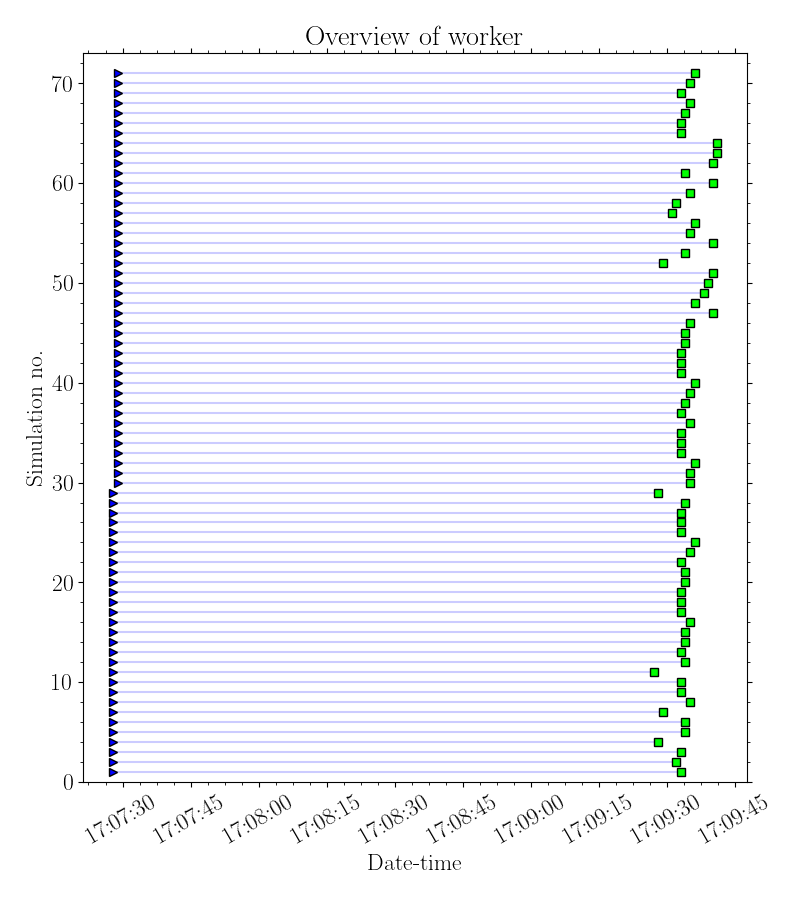

100%|██████████████████████████████████████████████████| 192000/192000 [01:23<00


All simulations finished successfully!
Average walltime per cpu  : 1.265 h
Fastest walltime for cpus : 0.217 h
Slowest walltime for cpus : 2.250 h


In [253]:
workerLog = f'{path}/slurm/slurm_sim1/worker.slurm.log55291090'
df = workerOverview(workerLog, paramFile, ofile=False, plot=True)

---
## Simulation statistics
---

In [232]:
lcs0 = LightCurve(path0, mode="multi")
lcs1 = LightCurve(path1, mode="multi")

### Overview table of simulations

In [224]:
# lcs0.stat_sim_table(f'{path}/table_sims0.ftr')

In [225]:
# lcs1.stat_sim_table(f'{path}/table_sims1.ftr')

### Statistics: LCs per star

In [6]:
# df1 = lcs1.stat_sims()
# df1.head()

In [7]:
# df5 = lcs5.stat_sims()
# df5.head()

### Statistics: LCs per star/quarter

In [9]:
# lcs1.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP1.txt')

In [10]:
# lcs.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP5.txt')

## LCs per camera

In [11]:
# from platosim.hpc import HPC 
# hpc = HPC(cpus=8)
# # hpc.run(script='platonium', project='kul20', paramFile=paramFile)

In [12]:
# statFile = '/lhome/nicholas/software/workdir/kul20/statistics.txt'
# df = pd.read_csv(statFile)

In [13]:
# df = df.rename(columns={'1': 'star', '1.1':'group', '1.2':'camera', '24':'quarter', '1.3':'flag'})

In [14]:
# df[df.flag == 0]

---
## Merge light curves
---

### Test single camera light curve

In [5]:
# Load and unpack data
lcs = LightCurve(f'{path}/000000010', mode="multi")
lcs.unpack()

# Load all files for a single star/group/camera
files = lcs.files('hdf5', group=1, camera=1)
lc = LightCurve(files[0])

# Load input model and sim-info table
dv = lc.varsource()
ds = lc.star()

# Merge all quarters
df = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1['time'] = lc.time()
    df1['flux'] = lc.flux(unit='ppt')
    df = pd.concat([df, df1])
    
# Stitch the light curve
lc = LightCurve(df, mode="multi")
df = lc.stitch(medpoint=1000)

# Plot comparison figure
fig, ax = lc.plot_stitch(df)
plt.plot(dv.time/86400, dv.flux, '-', c='orange', lw=2)
ax[0].set_ylabel('Flux [ppt]')
ax[1].set_ylabel('Flux [ppt]')
ds

[Error]: No files found! Check your path


SystemExit: 

/lhome/nicholas/anaconda3/envs/platonium/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [8]:
# Load and unpack data
lcs = LightCurve(f'{path}/output/000000001', mode="multi")
lcs.unpack()

# Load all files for a single star/group/camera
files = lcs.files('hdf5', group=1, camera=1)
lc = LightCurve(files[0])

# Load input model and sim-info table
dv = lc.varsource()
ds = lc.star()

# Merge all quarters
df = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1['time'] = lc.time()
    df1['flux'] = lc.flux(unit='ppt')
    df = pd.concat([df, df1])
    
# Stitch the light curve
lc = LightCurve(df, mode="multi")
df = lc.stitch(medpoint=1000, replace=True, plot=True)

# Linear detrend
df.flux = df.flux/1e3 + 1
lc = LightCurve(df, mode="multi")
df = lc.detrend(model='poly', degree=1, replace=False, segments=False)

# Plot comparison figure
fig, ax = lc.plot_detrend(df)
plt.plot(dv.time/86400, dv.flux, '-', c='lime', lw=1, label='Model')
ax[0].set_ylabel('Flux [ppt]')
ax[1].set_ylabel('Flux [ppt]')
ax[1].legend(loc='upper right')
ds

['/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q1.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q2.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q3.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q4.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q5.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q6.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q7.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q8.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q9.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q10.hdf5', '/lhome/nicholas/software/workdir/cs-smbhb/output/000000001/000000001_Ncam1.1_Q11.hdf5']


KeyError: "Unable to open object (object 'maskSPR' doesn't exist)"

### Test for combined camera light curve

In [ ]:
# Load and unpack data
lcs = LightCurve(f'{path2}/000000018', mode="multi")
lcs.unpack()

# Load input model
lc = LightCurve(lcs.files('hdf5')[0])
dv = lc.varsource()
ds = lc.star()

# Perform simple stitching and merge
df = lcs.merge_star(medpoint=1000)

# Plot 
lc = LightCurve(df, 'multi')
lc.plot(median_filter=1, alpha=0.05)
plt.plot(dv.time/86400, dv.flux, '-', c='orange', lw=2)
plt.ylabel('Flux [ppt]')
ds

### Produce final light curves

In [4]:
# Combine the two datasets while reducing each
from tqdm import tqdm
for i in tqdm(range(978,1001), bar_format=ut.tqdmBar()):
    starID = f'{i}'.zfill(9)
    
    # Light curves with contaminants
    
    # Signal injected
    lcs0 = LightCurve(f'{path}/sim0_signal/{starID}', mode="multi")
    lcs0.unpack()
    df0 = lcs0.merge_star()
    df = df0.rename(columns={'flux':'flux0_signal'})
    
    # Only noise
    lcs1 = LightCurve(f'{path}/sim0_noise/{starID}', mode="multi")
    lcs1.unpack()
    df1 = lcs1.merge_star()
    df['flux0_noise'] = df1.flux
        
    # Ligth curves without contaminants
    
    # Signal injected
    lcs2 = LightCurve(f'{path}/sim1_signal/{starID}', mode="multi")
    lcs2.unpack()
    df2 = lcs2.merge_star()
    df['flux1_signal'] = df2.flux
    
    # Only noise
    lcs3 = LightCurve(f'{path}/sim1_noise/{starID}', mode="multi")
    lcs3.unpack()
    df3 = lcs3.merge_star()
    df['flux1_noise'] = df3.flux

    # Save output file
    ofile = f'{path}/finals/{starID}.ftr'
    df.to_feather(ofile)
    os.system(f'chmod 755 {ofile}')

100%|██████████████████████████████████████████████████| 23/23 [01:27<00:00,  3.82s/it]                                                                                                                     


### Simulation tables

In [6]:
lcs = LightCurve(f'{path}/sim0_signal', mode='multi')
lcs.stat_sim_table(ofile=f'{path}/table_sim0.ftr')

100%|██████████████████████████████████████████████████| 1000/1000 [09:56<00:00,  1.68it/s]                                                                                                                 


,ID,PIC,ra,dec,mag,group,camera,quarter,rOA,xFP,yFP,ccd,xCCD,yCCD,ncon
0,1,11571238,95.125555,-47.494494,17.564157,1,1,1,4.332506,-17.996888,-5.269025,2,220.501372,3582.395116,3
1,1,11571238,95.125555,-47.494494,17.564157,1,1,2,8.993630,-5.219196,-38.825882,2,2084.771213,4292.266899,3
2,1,11571238,95.125555,-47.494494,17.564157,1,1,3,15.061494,-39.922763,-53.317395,2,2889.855257,2364.290950,3
3,1,11571238,95.125555,-47.494494,17.564157,1,1,4,12.685084,-52.611126,-18.331532,2,946.196245,1659.381910,3
4,1,11571238,95.125555,-47.494494,17.564157,1,1,5,4.333310,-17.999583,-5.272258,2,220.680979,3582.245411,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182821,1000,9984345,91.406091,-51.023193,17.175245,4,6,4,14.748671,-38.448582,52.607883,1,2063.810115,1659.562067,2
182822,1000,9984345,91.406091,-51.023193,17.175245,4,6,5,8.701685,-5.852688,37.428504,1,252.927111,2502.860906,2
182823,1000,9984345,91.406091,-51.023193,17.175245,4,6,6,4.676346,-19.371619,5.889008,1,1003.978806,4255.055110,2
182824,1000,9984345,91.406091,-51.023193,17.175245,4,6,7,12.661925,-51.982100,19.751867,1,2815.672223,3484.896251,2


In [8]:
lcs = LightCurve(f'{path}/sim1_signal', mode='multi')
lcs.stat_sim_table(ofile=f'{path}/table_sim1.ftr')

100%|██████████████████████████████████████████████████| 1000/1000 [10:21<00:00,  1.61it/s]                                                                                                                 


,ID,PIC,ra,dec,mag,group,camera,quarter,rOA,xFP,yFP,ccd,xCCD,yCCD,ncon
0,1,11571238,95.125555,-47.494494,17.564157,1,1,1,4.332506,-17.996888,-5.269025,2,220.501372,3582.395116,0
1,1,11571238,95.125555,-47.494494,17.564157,1,1,2,8.993630,-5.219196,-38.825882,2,2084.771213,4292.266899,0
2,1,11571238,95.125555,-47.494494,17.564157,1,1,3,15.061494,-39.922763,-53.317395,2,2889.855257,2364.290950,0
3,1,11571238,95.125555,-47.494494,17.564157,1,1,4,12.685084,-52.611126,-18.331532,2,946.196245,1659.381910,0
4,1,11571238,95.125555,-47.494494,17.564157,1,1,5,4.333310,-17.999583,-5.272258,2,220.680979,3582.245411,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182821,1000,9984345,91.406091,-51.023193,17.175245,4,6,4,14.748671,-38.448582,52.607883,1,2063.810115,1659.562067,0
182822,1000,9984345,91.406091,-51.023193,17.175245,4,6,5,8.701685,-5.852688,37.428504,1,252.927111,2502.860906,0
182823,1000,9984345,91.406091,-51.023193,17.175245,4,6,6,4.676346,-19.371619,5.889008,1,1003.978806,4255.055110,0
182824,1000,9984345,91.406091,-51.023193,17.175245,4,6,7,12.661925,-51.982100,19.751867,1,2815.672223,3484.896251,0


In [61]:

lcs = LightCurve(f'{path}/output', mode='multi')
df = lcs.stat_sim_table(ofile=f'{path}/table_star1.ftr')

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.76


In [62]:
df[df.quarter == 1]

,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon
0,1,11571238,95.125555,-47.494494,15.0,1,1,1,4,221.260120,3582.552741,4.332764,17.994051,5.282682,0
11,1,11571238,95.125555,-47.494494,15.0,1,2,1,4,213.984143,3589.812265,4.295462,17.863379,5.151715,0
22,1,11571238,95.125555,-47.494494,15.0,1,3,1,4,221.684944,3580.593934,4.341046,18.029309,5.290329,0
33,1,11571238,95.125555,-47.494494,15.0,1,4,1,4,229.167799,3572.925774,4.380304,18.167336,5.425020,0
44,1,11571238,95.125555,-47.494494,15.0,1,5,1,4,219.235652,3583.868345,4.325176,17.970370,5.246242,0
55,1,11571238,95.125555,-47.494494,15.0,1,6,1,4,220.912217,3581.991893,4.334588,18.004146,5.276420,0
66,1,11571238,95.125555,-47.494494,15.0,2,1,1,1,2088.806574,4289.347504,9.011472,-38.898518,5.271745,0
77,1,11571238,95.125555,-47.494494,15.0,2,2,1,1,2082.712490,4294.927859,8.983900,-38.788825,5.171299,0
88,1,11571238,95.125555,-47.494494,15.0,2,3,1,1,2079.264061,4299.337779,8.967650,-38.726753,5.091920,0
99,1,11571238,95.125555,-47.494494,15.0,2,4,1,1,2086.331107,4288.671732,9.001871,-38.853960,5.283909,0
